In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from itertools import product

import sys

from pathlib import Path
nb_dir = Path.cwd()
help_func_path = os.path.join(nb_dir,'helper_code')

sys.path.append(help_func_path) 

from plotting_functions import scatter_helper, plot_3d_scatters
from saving_functions import save_dataset,delete_dataset
from lmm_helper_funcs import latent_metric_model_gp

In [2]:
from scipy import stats
from sklearn.metrics.pairwise import rbf_kernel

In [3]:
DATA_ROOT = Path(os.environ["EPHEMERAL"]) / "pyspoc_synthetic_data"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

In [5]:
from sklearn.datasets import make_s_curve

In [44]:
def make_s_curve_custom(n_samples,noise,random_state=0,angle_scale=1.0,angle_phase_diff=0.0):
    """
    code adapted from sklearn.datasets.make_s_curve
    adds angle scaling and phase diff, to generate other 2d manifolds from the scurve
    """
    
    rng = np.random.default_rng(random_state)

    t = 3.0 * np.pi * (rng.uniform(size=(1, n_samples)) - 0.5)
    
    t_angle = angle_scale * t + angle_phase_diff*np.pi
    
    X = np.empty(shape=(n_samples, 3), dtype=np.float64)
    
    X[:, 0] = np.sin(t_angle)
    X[:, 1] = 2.0 * rng.uniform(size=n_samples)
    X[:, 2] = np.sign(t) * (np.cos(t_angle) - 1)
    
    X += noise * rng.standard_normal(size=(3, n_samples)).T
    t = np.squeeze(t)
    
    return X,t

In [ ]:
Z, y = make_s_curve_custom(n_samples=1000,noise=0.1, random_state=0,angle_scale=1.0,angle_phase_diff=0.0)

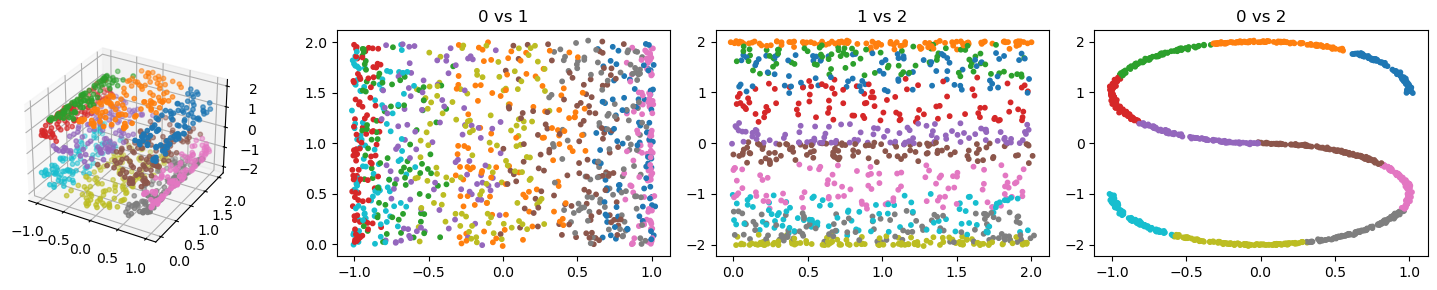

In [61]:
plot_3d_scatters(Z,'',y=y)

In [47]:
seed=0
random_states = {'latent' : seed+8291, 'gp' : seed+213, 'noise' : seed+4837}

X = latent_metric_model_gp(1000, 100, Z, 0.1, random_states, length_scale=1.0)

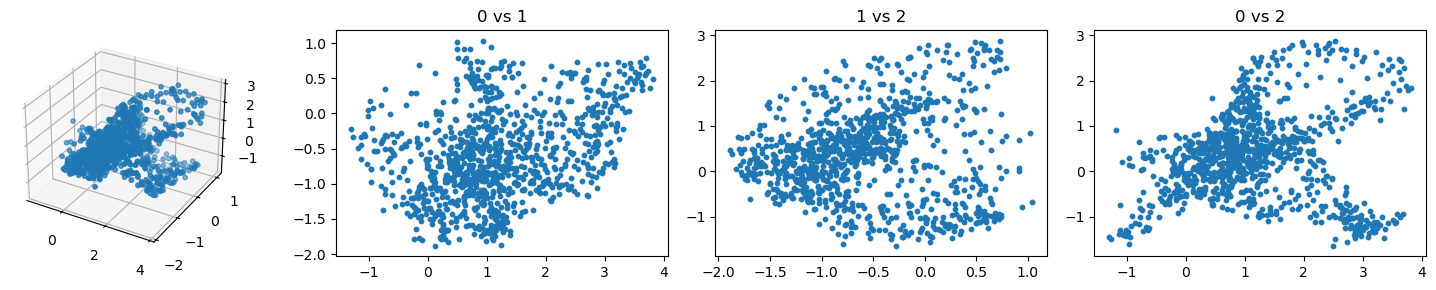

In [48]:
plot_3d_scatters(X,'')

In [66]:
# delete_dataset('gp_lmm_scurve',DATA_ROOT)

In [67]:
data_gen_name = 'gp_lmm_scurve'
category_lst = ['density']

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000,10000]
random_seeds_lst = [80,26759]

lmm_noise_param = 0.1 ## for noise added to gp
lmm_len_scale_param = 1 ## for rbf-kernel

sc_noise_lst = [0.01,0.1]

for n_samples, n_features in product(n_samples_lst, n_features_lst):
    
    print(n_samples, n_features)

    for sc_noise in sc_noise_lst:
            
        for sample_num,seed in enumerate(random_seeds_lst):
            
            random_states = {'latent' : seed+821, 'gp' : seed+323, 'noise' : seed+4237}
            
            Z,y = make_s_curve_custom(n_samples=n_samples,noise=sc_noise, random_state=random_states['latent'],angle_scale=1.0,angle_phase_diff=0.0)         
            X = latent_metric_model_gp(n_samples, n_features, Z, lmm_noise_param, random_states, length_scale=lmm_len_scale_param)
            
            params_dict = {
                'sc_noise' : sc_noise,
                'lmm_noise_param' : lmm_noise_param,
                'lmm_len_scale_param' : lmm_len_scale_param,
                'random_states_dict' : random_states
            }
            
            extra_arr = {
                'sc_univariate_pos_sklearn' : y
            }
                            
            try:
                save_dataset(X, 
                            generator=data_gen_name,
                            params=params_dict,
                            seed=seed,
                            category=category_lst,
                            extra_arrays=extra_arr, 
                            root=DATA_ROOT)
                del(X)
                
            except:
                print('error?')

1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000


In [70]:
m = pd.read_csv(DATA_ROOT / "manifest.csv")

generator = data_gen_name
params_lst = [f'params{i}' for i in range(0,100) if i%8==2]
m = m[(m.generator == generator) & (m.params_id.isin(params_lst))]
print(m.shape)
m

(8, 8)


,dataset_id,generator,category,n_rows,n_cols,params_id,seed,extra_files
4179,gp_lmm_scurve/params2/seed80_N1000_P10,gp_lmm_scurve,['density'],1000.0,10.0,params2,80.0,"[""sc_univariate_pos_sklearn_seed80.npy""]"
4183,gp_lmm_scurve/params2/seed80_N1000_P100,gp_lmm_scurve,['density'],1000.0,100.0,params2,80.0,"[""sc_univariate_pos_sklearn_seed80.npy""]"
4187,gp_lmm_scurve/params2/seed80_N1000_P1000,gp_lmm_scurve,['density'],1000.0,1000.0,params2,80.0,"[""sc_univariate_pos_sklearn_seed80.npy""]"
4191,gp_lmm_scurve/params2/seed80_N1000_P10000,gp_lmm_scurve,['density'],1000.0,10000.0,params2,80.0,"[""sc_univariate_pos_sklearn_seed80.npy""]"
4195,gp_lmm_scurve/params2/seed80_N10000_P10,gp_lmm_scurve,['density'],10000.0,10.0,params2,80.0,"[""sc_univariate_pos_sklearn_seed80.npy""]"
4199,gp_lmm_scurve/params2/seed80_N10000_P100,gp_lmm_scurve,['density'],10000.0,100.0,params2,80.0,"[""sc_univariate_pos_sklearn_seed80.npy""]"
4203,gp_lmm_scurve/params2/seed80_N10000_P1000,gp_lmm_scurve,['density'],10000.0,1000.0,params2,80.0,"[""sc_univariate_pos_sklearn_seed80.npy""]"
4207,gp_lmm_scurve/params2/seed80_N10000_P10000,gp_lmm_scurve,['density'],10000.0,10000.0,params2,80.0,"[""sc_univariate_pos_sklearn_seed80.npy""]"


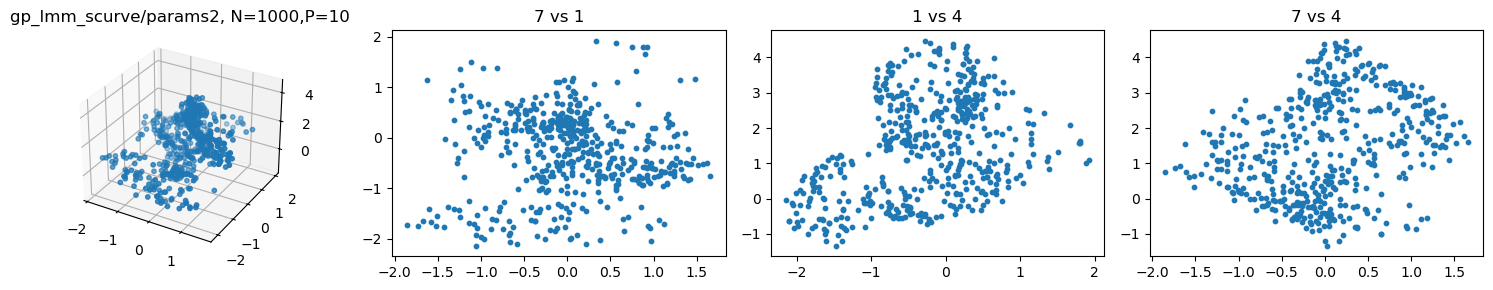

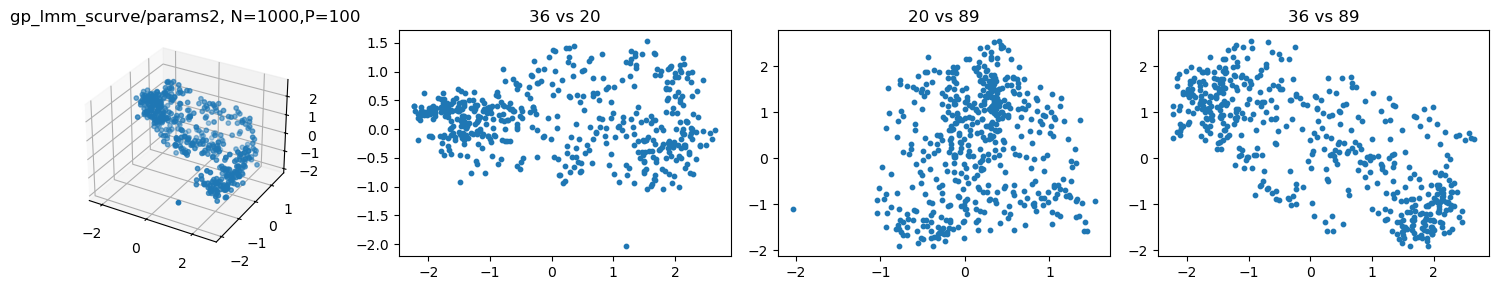

In [ ]:
max_pts = 500
for r in m.groupby(["generator", "params_id"]).head(2).itertuples():
    X = np.load(DATA_ROOT / f"{r.dataset_id}.npy")
    if len(X) > max_pts:
        rng = np.random.default_rng(0)       
        X = X[rng.choice(len(X), max_pts, replace=False)]
    plot_3d_scatters(X, f"{r.generator}/{r.params_id}, N={int(r.n_rows)},P={int(r.n_cols)}",custom_inx=np.random.choice(int(r.n_cols), 3, replace=False))

In [121]:
# m = pd.read_csv(DATA_ROOT / "manifest.csv")
# m['generator'].nunique(), 
# m.groupby(['n_rows','n_cols','generator'])['dataset_id'].count()

In [124]:
# m['generator'].unique()

## fragmented s curve manifolds

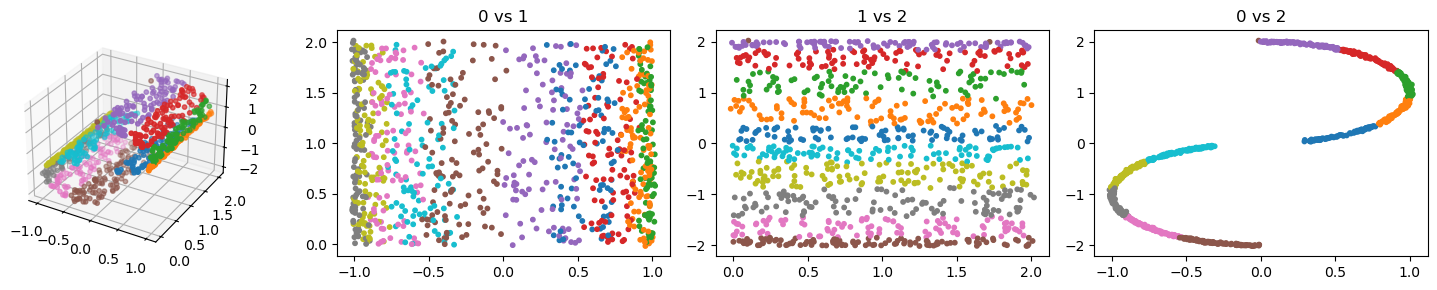

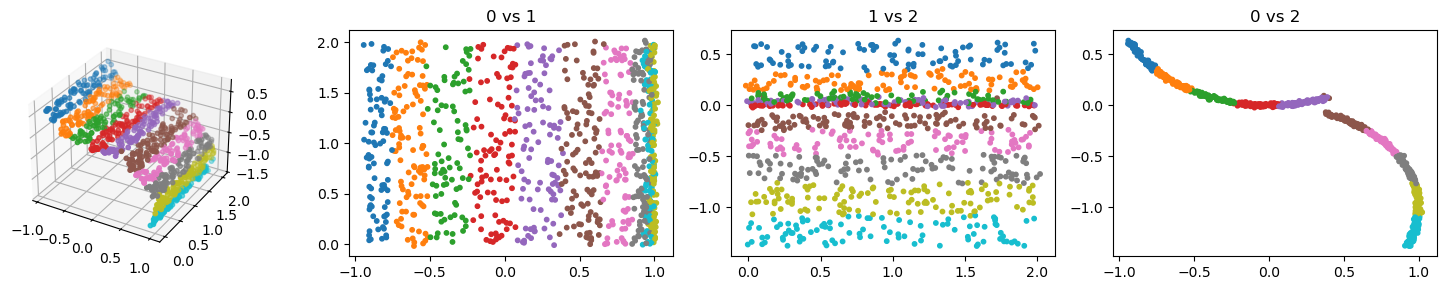

In [105]:
# fragmenetd s curves

Z, y = make_s_curve_custom(n_samples=1000,noise=0.01, random_state=0,angle_scale=0.6,angle_phase_diff=1.0)
plot_3d_scatters(Z,'',y=y)

Z, y = make_s_curve_custom(n_samples=1000,noise=0.01, random_state=0,angle_scale=1/3,angle_phase_diff=1/8)
plot_3d_scatters(Z,'',y=y)

In [106]:
data_gen_name = 'gp_lmm_scurve_fragmented'
category_lst = ['density']

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000,10000]
random_seeds_lst = [80,26759]

lmm_noise_param = 0.1 ## for noise added to gp
lmm_len_scale_param = 1 ## for rbf-kernel

sc_noise_lst = [0.01,0.1]

ang_scl_phase_lst = [(0.6,1.0),(1/3,1/8)]

for n_samples, n_features in product(n_samples_lst, n_features_lst):
    
    print(n_samples, n_features)

    for sc_noise in sc_noise_lst:
        
        for angl_params in ang_scl_phase_lst:
            
            for sample_num,seed in enumerate(random_seeds_lst):
                
                random_states = {'latent' : seed+821, 'gp' : seed+323, 'noise' : seed+4237}
                
                angle_scale = angl_params[0]
                angle_phase = angl_params[1]
                
                Z,y = make_s_curve_custom(n_samples=n_samples,noise=sc_noise, random_state=random_states['latent'],angle_scale=angle_scale,angle_phase_diff=angle_phase)         
                X = latent_metric_model_gp(n_samples, n_features, Z, lmm_noise_param, random_states, length_scale=lmm_len_scale_param)
                
                params_dict = {
                    'sc_noise' : sc_noise,
                    'lmm_noise_param' : lmm_noise_param,
                    'lmm_len_scale_param' : lmm_len_scale_param,
                    'random_states_dict' : random_states,
                    'angle_scale' : angle_scale,
                    'angle_phase_diff' : angle_phase,
                    'method' : 'make_s_curve_custom sampler'
                }
                
                extra_arr = {
                    'sc_univariate_pos_sklearn' : y
                }
                                
                try:
                    save_dataset(X, 
                                generator=data_gen_name,
                                params=params_dict,
                                seed=seed,
                                category=category_lst,
                                extra_arrays=extra_arr, 
                                root=DATA_ROOT)
                    del(X)
                    
                except:
                    print('error?')

1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000


# 8 and fragmented 8 manifolds

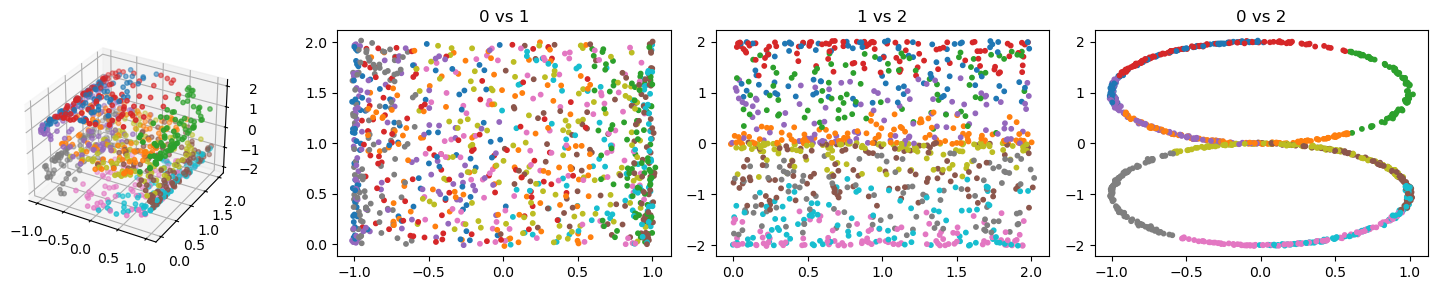

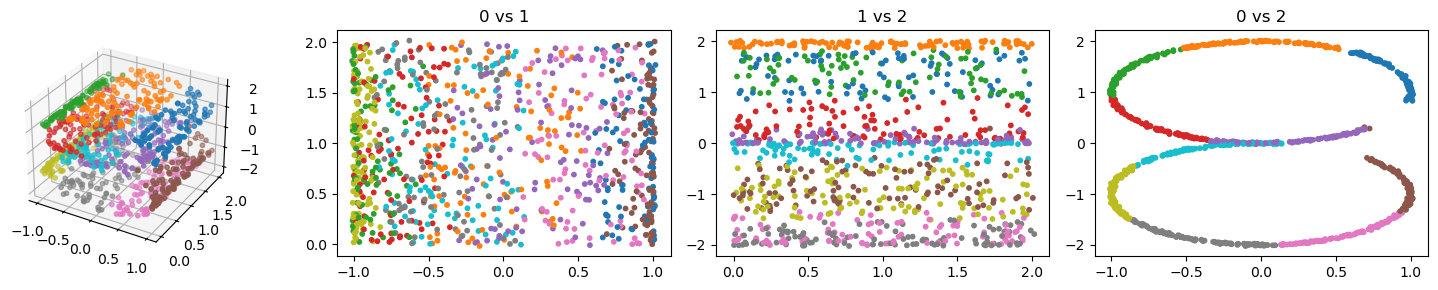

In [107]:
# 8 and fragmented 8

Z, y = make_s_curve_custom(n_samples=1000,noise=0.01, random_state=0,angle_scale=2.0,angle_phase_diff=0.0)
plot_3d_scatters(Z,'',y=y)

Z, y = make_s_curve_custom(n_samples=1000,noise=0.01, random_state=0,angle_scale=1.2,angle_phase_diff=1/4)
plot_3d_scatters(Z,'',y=y)

In [108]:
data_gen_name = 'gp_lmm_eight'
category_lst = ['density']

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000,10000]
random_seeds_lst = [80,26759]

lmm_noise_param = 0.1 ## for noise added to gp
lmm_len_scale_param = 1 ## for rbf-kernel

sc_noise_lst = [0.01,0.1]

ang_scl_phase_lst = [(2.0,0.0),(1.2,1/4)]

for n_samples, n_features in product(n_samples_lst, n_features_lst):
    
    print(n_samples, n_features)

    for sc_noise in sc_noise_lst:
        
        for angl_params in ang_scl_phase_lst:
            
            for sample_num,seed in enumerate(random_seeds_lst):
                
                random_states = {'latent' : seed+821, 'gp' : seed+323, 'noise' : seed+4237}
                
                angle_scale = angl_params[0]
                angle_phase = angl_params[1]
                
                Z,y = make_s_curve_custom(n_samples=n_samples,noise=sc_noise, random_state=random_states['latent'],angle_scale=angle_scale,angle_phase_diff=angle_phase)         
                X = latent_metric_model_gp(n_samples, n_features, Z, lmm_noise_param, random_states, length_scale=lmm_len_scale_param)
                
                params_dict = {
                    'sc_noise' : sc_noise,
                    'lmm_noise_param' : lmm_noise_param,
                    'lmm_len_scale_param' : lmm_len_scale_param,
                    'random_states_dict' : random_states,
                    'angle_scale' : angle_scale,
                    'angle_phase_diff' : angle_phase,
                    'method' : 'make_s_curve_custom sampler'
                }
                
                extra_arr = {
                    'sc_univariate_pos_sklearn' : y
                }
                                
                try:
                    save_dataset(X, 
                                generator=data_gen_name,
                                params=params_dict,
                                seed=seed,
                                category=category_lst,
                                extra_arrays=extra_arr, 
                                root=DATA_ROOT)
                    del(X)
                    
                except:
                    print('error?')

1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000
